# Model-reality check

This secton works for reality check for our best model. We are planning to apply the best classifier to the unlabeled data to get qualitive evaluation on how our model can be generalized to future data.

In [1]:
import pandas as pd
import numpy as np
import os
import json
import feature_engineering
import get_embedding
import matplotlib.pyplot as plt

## Load data

In [2]:
# copy the file path from run_get_embedding.py
config_path = "configs/exp_029_finetune.yaml"
weights_path = "../results/exp_029/exp_029_finetune.pt"

In [3]:
unlabelled_data_path = ['../data/O002539.npz', '../data/O002772.npz', '../data/O003005.npz']

# get embeddings for unlabelled data
# if the embedding files already exist, this step will be skipped
if not all(os.path.exists(os.path.join("../data", os.path.basename(fp).replace(".npz", "_ae.csv"))) for fp in unlabelled_data_path):
    get_embedding.get_embedding(
        config_path=config_path,
        weights_path=weights_path,
        labeled_only=False,
        filepaths= unlabelled_data_path ,
        data_dir="../data",
        output_dir="../data"
        )
else:
    print("Embedding files already exist. Skipping embedding generation.")

Embedding files already exist. Skipping embedding generation.


In [4]:
if not all(os.path.exists(os.path.join("../data", os.path.basename(fp).replace(".npz", ".csv"))) for fp in unlabelled_data_path):
    feature_engineering.feature_engineering(
        data_dir="../data",
        path_output='../data',
        embedding_dir='../data',
        labeled_only=False,
        filepaths=unlabelled_data_path,
    )
else:
    print("Feature engineered files already exist. Skipping feature engineering.")

Feature engineered files already exist. Skipping feature engineering.


In [5]:
# prepare data for model reality check

unlabelled_dfs = []
for fp in unlabelled_data_path:
    df = pd.read_csv(os.path.join("../data", os.path.basename(fp).replace(".npz", ".csv")))
    unlabelled_dfs.append(df)
unlabelled_data = pd.concat(unlabelled_dfs, ignore_index=True)
unlabelled_data.head()

,image_id,y,x,NDAI,SD,CORR,DF,CF,BF,AF,...,AN_13_mean,AN_13_max,ae0,ae1,ae2,ae3,ae4,ae5,ae6,ae7
0,O002539,2.0,67.0,0.252645,989.380432,-0.037011,25854.75,24105.50,21934.50,17938.25,...,-2.343011,0.219334,0.393310,2.594390,0.423518,-3.219439,0.954110,-3.037111,-1.086493,-2.859196
1,O002539,2.0,68.0,0.221815,1321.251465,0.035111,26651.00,23038.50,22098.50,19068.25,...,-2.139327,0.219334,-0.074816,2.378241,1.386875,-3.903569,0.234184,-2.613527,-1.283378,-1.376580
2,O002539,2.0,69.0,0.231423,984.155518,-0.217875,27540.00,20284.00,20124.25,19210.75,...,-1.952633,0.219334,-0.308607,2.162305,2.459094,-4.282087,-1.411938,-2.201149,-1.437614,0.021992
3,O002539,2.0,70.0,0.251133,853.619812,-0.077692,27950.00,19708.00,20084.25,20451.75,...,-1.781456,0.219334,-0.559064,1.031979,3.497119,-4.385611,-3.461870,-1.727835,-1.467870,1.608135
4,O002539,2.0,71.0,0.215065,1091.303223,-0.090391,27342.75,20977.25,20246.75,21187.50,...,-1.608773,0.219334,1.048877,-0.504447,0.554444,-0.726480,0.259593,-0.250959,-0.303440,0.359496


## Load model

In [6]:
# load the best classifier 
import joblib
# Load model
model = joblib.load("lgb_model.pkl")

selected_features = model.feature_name_

/Users/dannyzhou/anaconda3/envs/env_214_test/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
X_unlabelled = unlabelled_data[selected_features]
# get predicted probabilities
y_unlabelled_pred = model.predict(X_unlabelled)
y_unlabelled_prob = model.predict_proba(X_unlabelled)[:, 1]
# add predicted probabilities to the dataframe
unlabelled_data["y_prob"] = y_unlabelled_prob
unlabelled_data["y_pred"] = y_unlabelled_pred
unlabelled_data.head()


/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/639408388.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  unlabelled_data["y_prob"] = y_unlabelled_prob
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/639408388.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  unlabelled_data["y_pred"] = y_unlabelled_pred


,image_id,y,x,NDAI,SD,CORR,DF,CF,BF,AF,...,ae0,ae1,ae2,ae3,ae4,ae5,ae6,ae7,y_prob,y_pred
0,O002539,2.0,67.0,0.252645,989.380432,-0.037011,25854.75,24105.50,21934.50,17938.25,...,0.393310,2.594390,0.423518,-3.219439,0.954110,-3.037111,-1.086493,-2.859196,1.0,1.0
1,O002539,2.0,68.0,0.221815,1321.251465,0.035111,26651.00,23038.50,22098.50,19068.25,...,-0.074816,2.378241,1.386875,-3.903569,0.234184,-2.613527,-1.283378,-1.376580,1.0,1.0
2,O002539,2.0,69.0,0.231423,984.155518,-0.217875,27540.00,20284.00,20124.25,19210.75,...,-0.308607,2.162305,2.459094,-4.282087,-1.411938,-2.201149,-1.437614,0.021992,1.0,1.0
3,O002539,2.0,70.0,0.251133,853.619812,-0.077692,27950.00,19708.00,20084.25,20451.75,...,-0.559064,1.031979,3.497119,-4.385611,-3.461870,-1.727835,-1.467870,1.608135,1.0,1.0
4,O002539,2.0,71.0,0.215065,1091.303223,-0.090391,27342.75,20977.25,20246.75,21187.50,...,1.048877,-0.504447,0.554444,-0.726480,0.259593,-0.250959,-0.303440,0.359496,1.0,1.0


## Check

### 0. Prediction summary

In [8]:
pred_summary = (
        unlabelled_data.groupby("image_id")
        .agg(
            n_pixels=("y_pred", "size"),
            mean_prob=("y_prob", "mean"),
            median_prob=("y_prob", "median"),
            std_prob=("y_prob", "std"),
            cloud_rate=("y_pred", "mean"),
            min_prob=("y_prob", "min"),
            max_prob=("y_prob", "max"),
        )
        .reset_index()
)

In [9]:
pred_summary.round(4)

,image_id,n_pixels,mean_prob,median_prob,std_prob,cloud_rate,min_prob,max_prob
0,O002539,115378,0.8827,1.0000,0.3015,0.8851,0.0,1.0
1,O002772,115668,0.0808,0.0000,0.2607,0.0805,0.0,1.0
2,O003005,115923,0.7531,0.9999,0.4086,0.7557,0.0,1.0


In [10]:
# save stats for report (latex table)
output_table = pred_summary.round(4).to_latex(index=False)
with open("../report/unlabelled_prediction_summary.tex", "w") as f:
    f.write(output_table)

### 1. Spatial Visualization

In [11]:
def make_image_grid(df_img, value_col):
    """
    Convert a long-format dataframe for one image into a 2D grid.
    Assumes x_coord, y_coord identify unique pixel positions.
    """
    grid = df_img.pivot(index="y", columns="x", values=value_col)
    return grid.sort_index(ascending=True)

def plot_prediction_maps(df, image_id, prob_col="y_prob", label_col="y_pred"):
    df_img = df[df["image_id"] == image_id].copy()

    prob_grid = make_image_grid(df_img, prob_col)
    label_grid = make_image_grid(df_img, label_col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(prob_grid, origin="lower", aspect="auto")
    axes[0].set_title(f"{image_id} - Predicted Probability")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(label_grid, origin="lower", aspect="auto")
    axes[1].set_title(f"{image_id} - Predicted Label")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xlabel("x_coord")
        ax.set_ylabel("y_coord")

    plt.tight_layout()
    plt.show()

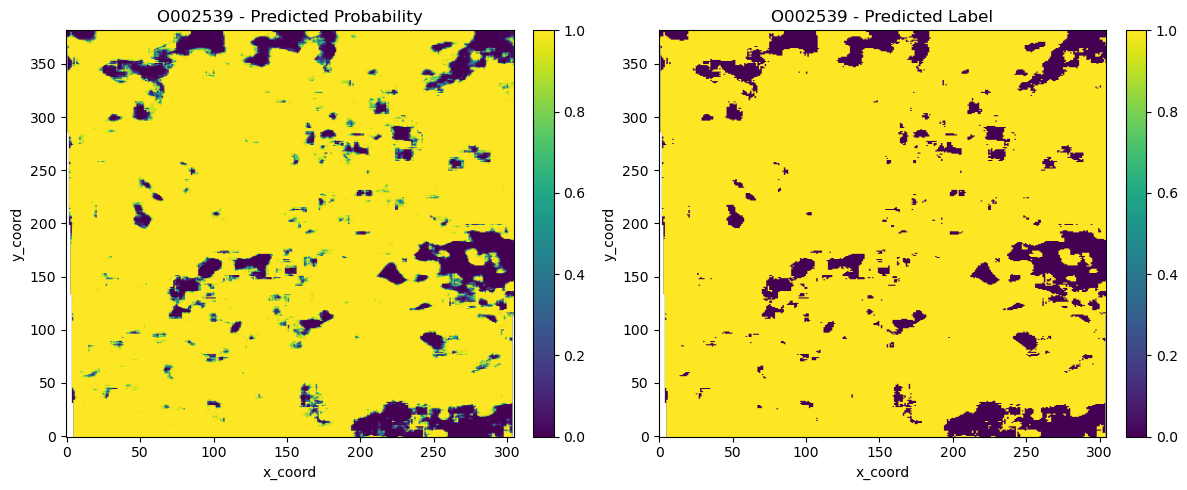

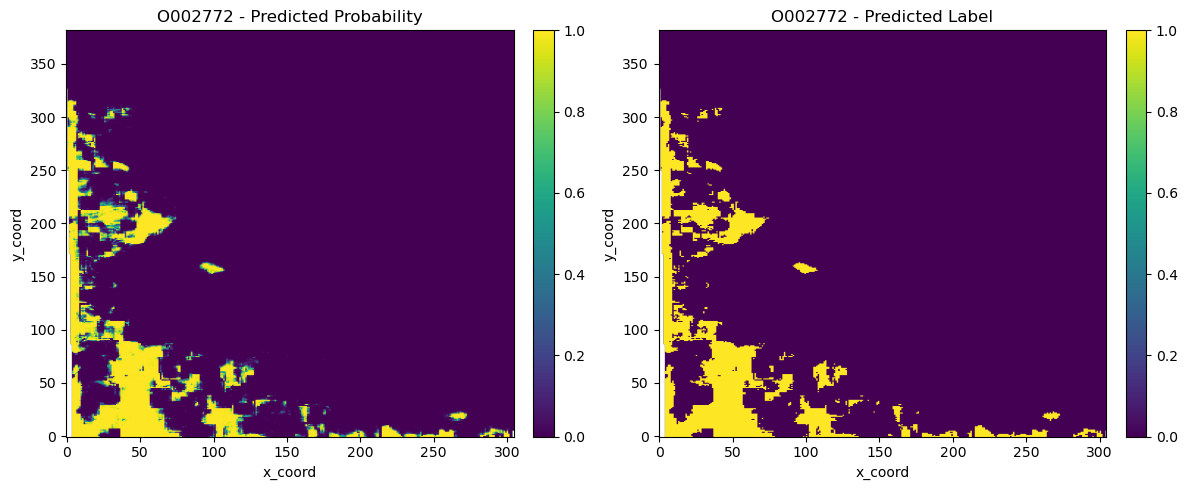

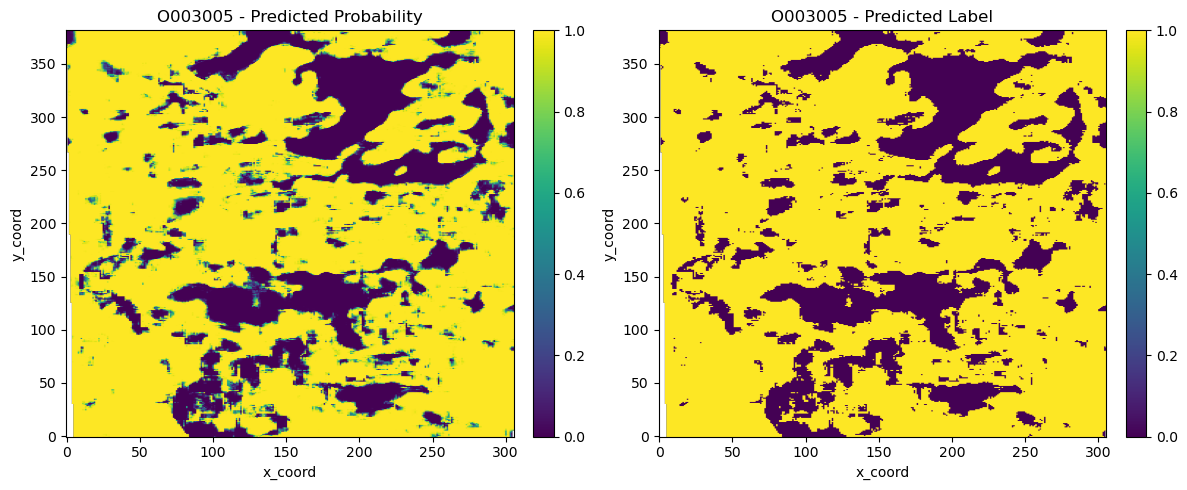

In [12]:
for img_id in unlabelled_data["image_id"].unique():
    plot_prediction_maps(unlabelled_data, img_id)

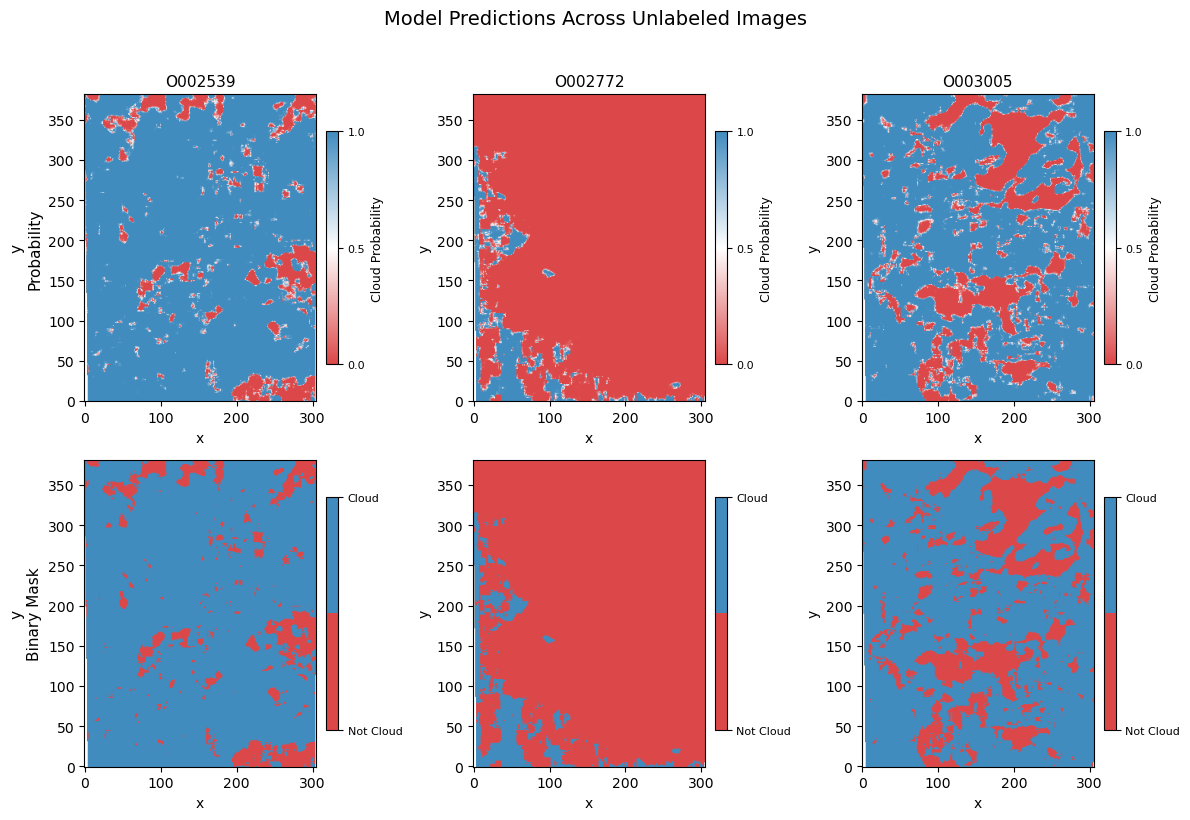

In [13]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

image_ids = list(unlabelled_data["image_id"].unique())
n = len(image_ids)

# continuous colormap for probability: red -> white -> blue
prob_cmap = LinearSegmentedColormap.from_list(
    "cloud_prob_cmap",
    ["#d62728", "#ffffff", "#1f77b4"]
)

# discrete colormap for binary mask: red = not cloud, blue = cloud
mask_cmap = ListedColormap(["#d62728", "#1f77b4"])

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

# handle single image edge case
if n == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for j, image_id in enumerate(image_ids):
    df_img = unlabelled_data[unlabelled_data["image_id"] == image_id].copy()

    prob_grid = make_image_grid(df_img, "y_prob")
    label_grid = make_image_grid(df_img, "y_pred")

    # ---- Row 1: Probability ----
    im0 = axes[0, j].imshow(
        prob_grid,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap=prob_cmap,
        alpha=0.85
    )
    axes[0, j].set_title(f"{image_id}", fontsize=11)
    axes[0, j].set_xlabel("x")
    axes[0, j].set_ylabel("y")

    cbar0 = fig.colorbar(im0, ax=axes[0, j], fraction=0.046, pad=0.04)
    cbar0.set_ticks([0, 0.5, 1])
    cbar0.set_label("Cloud Probability", fontsize=9)
    cbar0.ax.tick_params(labelsize=8)

    # ---- Row 2: Binary mask ----
    im1 = axes[1, j].imshow(
        label_grid,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap=mask_cmap,
        alpha=0.85
    )
    axes[1, j].set_xlabel("x")
    axes[1, j].set_ylabel("y")

    cbar1 = fig.colorbar(im1, ax=axes[1, j], fraction=0.046, pad=0.04)
    cbar1.set_ticks([0, 1])
    cbar1.set_ticklabels(["Not Cloud", "Cloud"])
    cbar1.ax.tick_params(labelsize=8)

# Row labels
axes[0, 0].set_ylabel("y\nProbability", fontsize=11)
axes[1, 0].set_ylabel("y\nBinary Mask", fontsize=11)

# Global title
plt.suptitle("Model Predictions Across Unlabeled Images", fontsize=14, y=1.02)

plt.tight_layout()

# optional: save for report
plt.savefig("../figs/prediction_panel_unlabeled.png", dpi=300, bbox_inches="tight")

plt.show()

Comment:

Based on the 2D visualization, the predicted probability and predicted label are very close, which gives us an intuition that the probabilities are very likely to **concentrate around 0 and 1**. 

### 2. Histogram of probability

In [14]:
def plot_probability_histograms(df, bins=50):
    image_ids = df["image_id"].unique()
    n = len(image_ids)

    fig, axes = plt.subplots(n, 1, figsize=(8, 4 * n))
    if n == 1:
        axes = [axes]

    for ax, img_id in zip(axes, image_ids):
        df_img = df[df["image_id"] == img_id]
        ax.hist(df_img["y_prob"], bins=bins)
        ax.set_title(f"{img_id} - Prediction Probability Distribution")
        ax.set_xlabel("y_prob")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

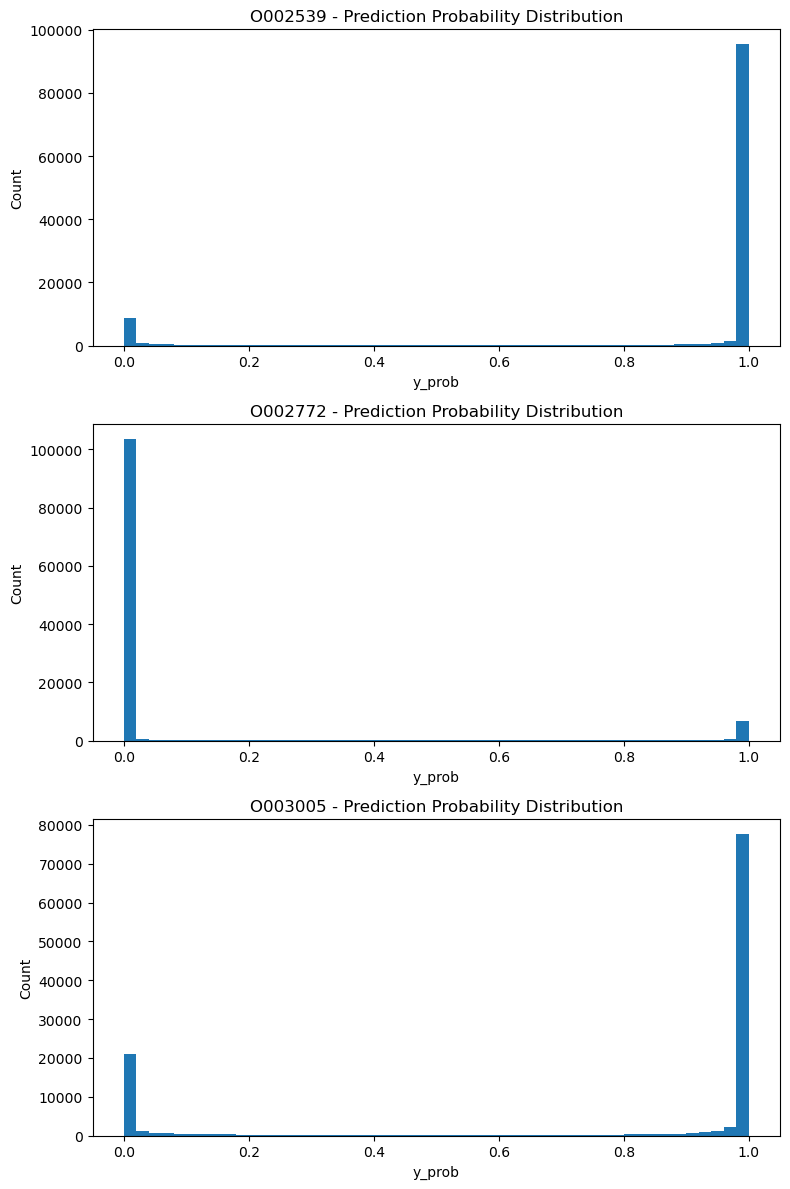

In [15]:
plot_probability_histograms(unlabelled_data)

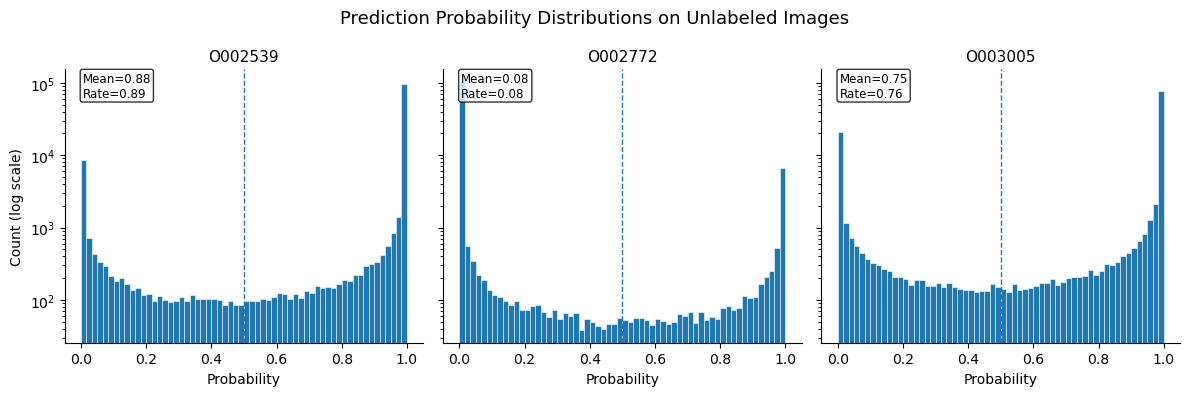

In [16]:
plt.style.use("default")

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, image_id in zip(axes, image_ids):
    df_img = unlabelled_data[unlabelled_data["image_id"] == image_id]
    probs = df_img["y_prob"].dropna().values

    mean_prob = probs.mean()
    cloud_rate = (probs >= 0.5).mean()

    ax.hist(probs, bins=60, edgecolor="white", linewidth=0.4)

    # decision boundary
    ax.axvline(0.5, linestyle="--", linewidth=1)

    # log scale (KEY improvement)
    ax.set_yscale("log")

    ax.set_title(image_id, fontsize=11)
    ax.set_xlabel("Probability")

    # cleaner style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # annotation (simplified)
    ax.text(
        0.05, 0.9,
        f"Mean={mean_prob:.2f}\nRate={cloud_rate:.2f}",
        transform=ax.transAxes,
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8)
    )

axes[0].set_ylabel("Count (log scale)")

plt.suptitle("Prediction Probability Distributions on Unlabeled Images", fontsize=13)

plt.tight_layout()
plt.savefig("../figs/probability_histograms_unlabeled.png", dpi=300, bbox_inches="tight")
plt.show()

**Comment**:

The prediction probability distributions for the three unlabeled images show that most predicted probabilities are concentrated near 0 and 1. This indicates that the model produces highly confident predictions rather than uncertain ones. Such behavior suggests that the decision boundary is sharp, insensitive to threshold. However, since we are evaluating on the unlabelled data, this high level of confidence leads us to caution about overfitting or sensitvity to training data distribution.

### 3. Threshold sensitivity check

Since we originially use the default threshold 0.5, we want to see whether the mask will change as the threshold changes.

In [17]:
threshold_check_results = []
thresholds = np.arange(0.1, 0.9, 0.1)

for img_id in unlabelled_data["image_id"].unique():
    df_img = unlabelled_data[unlabelled_data["image_id"] == img_id].copy()
    total_pixels = len(df_img)
    for thresh in thresholds:
        cloud_pixels = (df_img["y_prob"] >= thresh).sum()
        cloud_rate = cloud_pixels / total_pixels
        threshold_check_results.append({
            "image_id": img_id,
            "threshold": thresh,
            "cloud_rate": cloud_rate
        })
threshold_check_df = pd.DataFrame(threshold_check_results)
threshold_check_df.pivot(index="image_id", columns="threshold", values="cloud_rate").round(4)


threshold,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8
image_id,,,,,,,,
O002539,0.9089,0.9007,0.8954,0.8899,0.8851,0.8798,0.8737,0.8660
O002772,0.0946,0.0896,0.0858,0.0829,0.0805,0.0778,0.0750,0.0720
O003005,0.7934,0.7799,0.7709,0.7630,0.7557,0.7482,0.7393,0.7281


**Comment**:

Since our predicted probability is very extreme, it makes sense the predicted label is insensitive to the change of threshold.

### 4. Connected component analysis

In cloud detection task, in most of the cases, we expect to see that group neiboring pixels that share the same label into coherent regions.

Thus we carry out CCA, which will find clusters of adjencent cloud pixels and treat each cluster as one "connected region".

Real clouds are usually spatiallyy continuous and have smooth regions. What we want see in CCA is the predicted image has few components, large, smooth regions and low number of tiny isolated pixels.

In [18]:
from scipy.ndimage import label
def connected_component_stats(df, image_id, label_col="y_pred", small_threshold=25):
    df_img = df[df["image_id"] == image_id].copy()
    label_grid = make_image_grid(df_img, label_col)

    binary_mask = label_grid.values.astype(int)

    structure = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ])

    labeled_array, num_features = label(binary_mask, structure=structure)

    component_sizes = []
    for comp_id in range(1, num_features + 1):
        size = np.sum(labeled_array == comp_id)
        component_sizes.append(size)

    if len(component_sizes) == 0:
        return {
            "image_id": image_id,
            "num_components": 0,
            "largest_component": 0,
            "mean_component_size": 0,
            "small_component_ratio": 0
        }

    component_sizes = np.array(component_sizes)

    return {
        "image_id": image_id,
        "num_components": int(num_features),
        "largest_component": int(component_sizes.max()),
        "mean_component_size": float(component_sizes.mean()),
        "small_component_ratio": float(np.mean(component_sizes <= small_threshold))
    }

In [19]:
cc_stats = pd.DataFrame(
    [connected_component_stats(unlabelled_data, img_id) for img_id in unlabelled_data["image_id"].unique()]
)
print(cc_stats)

  image_id  num_components  largest_component  mean_component_size  \
0  O002539              50             101540          2042.340000   
1  O002772              95               4845            97.978947   
2  O003005              65              87105          1347.676923   

   small_component_ratio  
0               0.860000  
1               0.747368  
2               0.923077  


/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2419848503.py:6: RuntimeWarning: invalid value encountered in cast
  binary_mask = label_grid.values.astype(int)
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2419848503.py:6: RuntimeWarning: invalid value encountered in cast
  binary_mask = label_grid.values.astype(int)
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2419848503.py:6: RuntimeWarning: invalid value encountered in cast
  binary_mask = label_grid.values.astype(int)


In [ ]:
# save the connected component stats for report
# reports_dir = "../report"
# os.makedirs(reports_dir, exist_ok=True)
# cc_latex_table = cc_stats.to_latex(
#     index=False,
#     float_format="%.2f",
#     caption="Connected Component Statistics for Predicted Cloud Masks",
#     label="tab:cc_stats",
#     column_format="lcccc",
# )
# with open(os.path.join(reports_dir, "connected_component_stats.tex"), "w") as f:
#     f.write(cc_latex_table)

**Comment**:

Connected-component analysis shows that the predicted cloud masks contain large coherent regions, particularly for O002539 and O003005, where the largest connected components are substantial. This supports the visual impression that the model captures large-scale cloud structure. At the same time, the high proportion of small connected components across all three images suggests the presence of fragmented edge predictions or isolated noise. O002772 appears noticeably more fragmented than the other two images, indicating weaker spatial coherence on that image.

### 5. Feature-level sanity check

Our three expert features are good source of sanity check. We can inspect whether we have expected feature distribution difference between our predicted label.

In [21]:
def plot_feature_by_prediction(df, feature_col, label_col="y_pred"):
    fig, ax = plt.subplots(figsize=(6, 4))

    cloud_vals = df[df[label_col] == 1][feature_col].dropna()
    noncloud_vals = df[df[label_col] == 0][feature_col].dropna()

    ax.boxplot([noncloud_vals, cloud_vals], labels=["pred=0", "pred=1"])
    ax.set_title(f"{feature_col} by Predicted Label")
    ax.set_ylabel(feature_col)

    plt.tight_layout()
    plt.show()

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2634690674.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([noncloud_vals, cloud_vals], labels=["pred=0", "pred=1"])


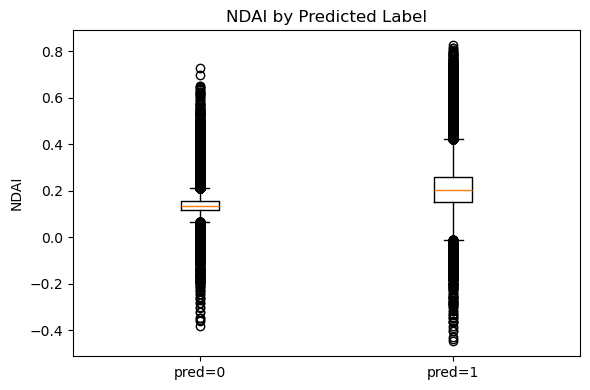

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2634690674.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([noncloud_vals, cloud_vals], labels=["pred=0", "pred=1"])


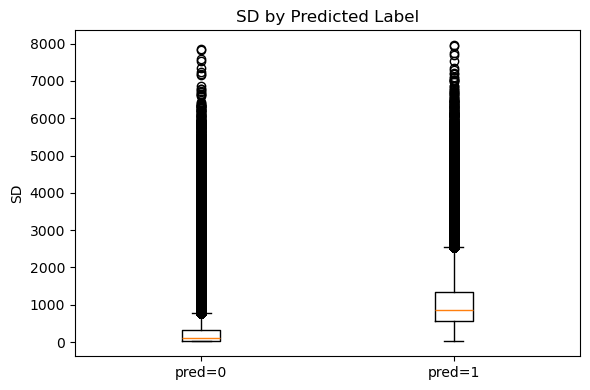

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/2634690674.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([noncloud_vals, cloud_vals], labels=["pred=0", "pred=1"])


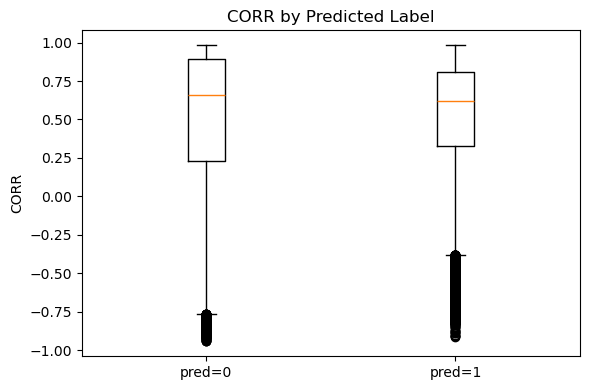

In [22]:
plot_feature_by_prediction( unlabelled_data, "NDAI")
plot_feature_by_prediction(unlabelled_data, "SD")
plot_feature_by_prediction(unlabelled_data, "CORR")

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/424856348.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/424856348.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_39198/424856348.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


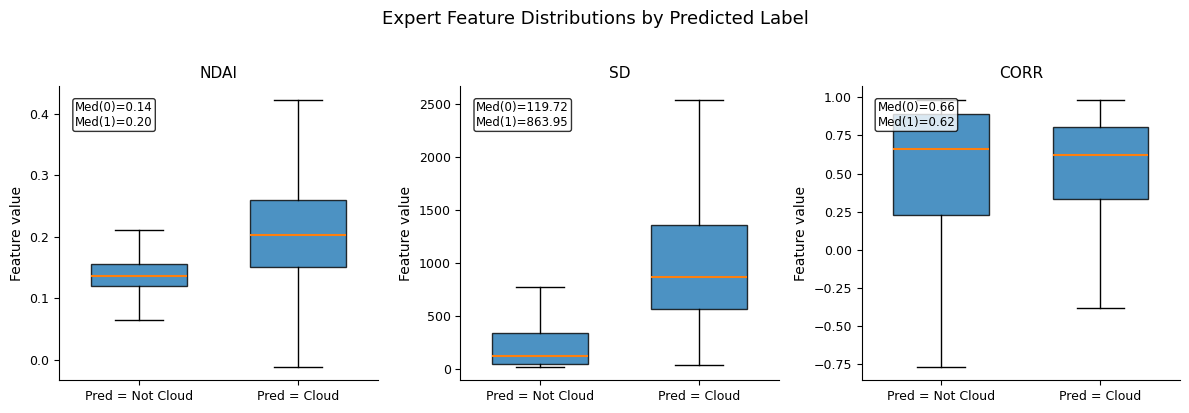

In [23]:
# report-style
# three expert features
features = ["NDAI", "SD", "CORR"] 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, feature in enumerate(features):
    ax = axes[i]

    cloud_vals = unlabelled_data[unlabelled_data["y_pred"] == 1][feature].dropna()
    noncloud_vals = unlabelled_data[unlabelled_data["y_pred"] == 0][feature].dropna()

    bp = ax.boxplot(
        [noncloud_vals, cloud_vals],
        labels=["Pred = Not Cloud", "Pred = Cloud"],
        patch_artist=True,
        widths=0.6,
        showfliers=False
    )

    # simple clean styling
    for box in bp["boxes"]:
        box.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_linewidth(1.5)

    ax.set_title(feature, fontsize=11)
    ax.set_ylabel("Feature value", fontsize=10)

    # remove clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=9)

    # add median annotation
    med0 = np.median(noncloud_vals)
    med1 = np.median(cloud_vals)

    ax.text(
        0.05, 0.95,
        f"Med(0)={med0:.2f}\nMed(1)={med1:.2f}",
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8)
    )

plt.suptitle("Expert Feature Distributions by Predicted Label", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figs/feature_boxplots_unlabeled.png", dpi=300, bbox_inches="tight")
plt.show()